In [2]:
!pip install vaderSentiment groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 8.5 MB/s eta 0:00:00


Loaded: 355 entries
  Improved    : 165
  Not improved: 190
  INTENTION   : 71
  REFLECTION  : 262

Extracting Tier 1 linguistic features...
  Done.

TIER 1 — IMPROVED vs NOT-IMPROVED: FEATURE COMPARISON

Feature                               Improved   Not Impr    p-value  Sig?
---------------------------------------------------------------------------
  Word count                            31.000     27.000     0.4621  n.s.
  Lexical richness (TTR)                 0.848      0.857     0.8093  n.s.
  Specificity score (composite)          1.000      1.000     0.6322  n.s.
  Quantity markers (e.g. "30 min")       0.000      0.000     0.6494  n.s.
  Time markers (e.g. "tomorrow")         0.000      0.000     0.5162  n.s.
  Activity words                         0.000      0.000     0.5116  n.s.
  Sentiment (compound)                   0.518      0.458     0.1750  n.s.
  Positive emotion                       0.141      0.132     0.7795  n.s.
  Negative emotion                       0.0

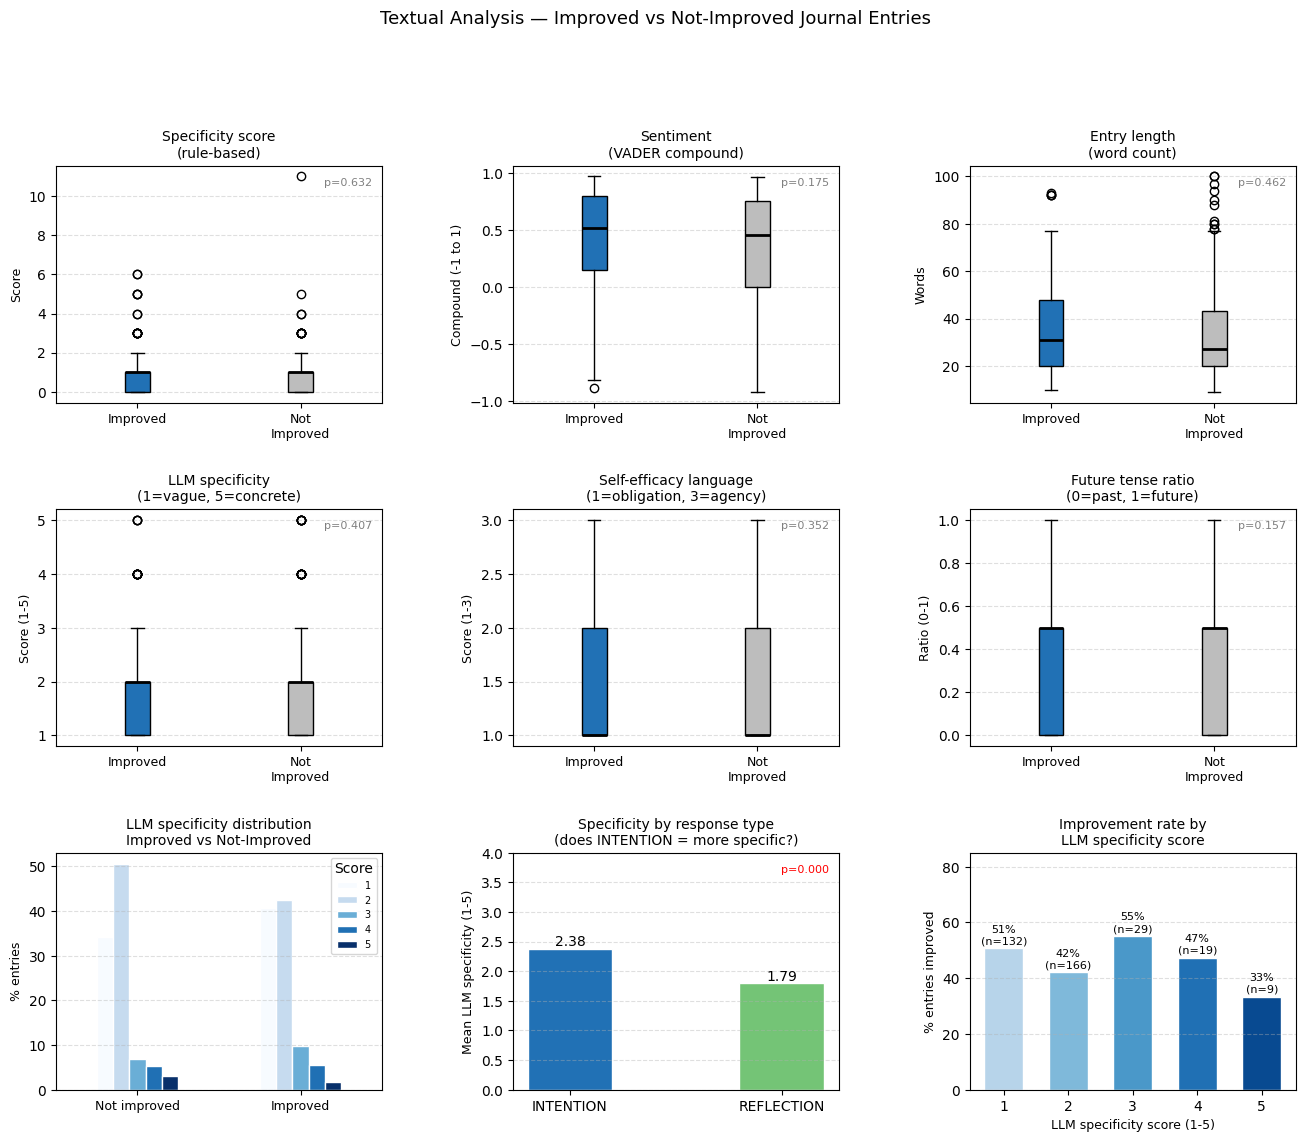

Saved → textual_analysis_plots.png


Saved → textual_analysis_results.csv
Saved → textual_features.csv
Saved → textual_llm_scores.csv

All textual analyses complete.


In [20]:
"""
textual_analysis.py
--------------------
Linguistic analysis of improved vs non-improved journal entries.

Research question:
  Do journal entries that precede behavioral improvement differ
  linguistically from those that don't — regardless of INTENTION
  vs REFLECTION classification?

Tier 1 — rule-based (no LLM):
  T1a. Specificity markers (numbers, time words, named activities)
  T1b. Sentiment (VADER)
  T1c. Entry length and lexical richness
  T1d. Temporal orientation (future vs past tense ratio)

Tier 2 — LLM-rated via Groq:
  T2a. Specificity score (1–5)
  T2b. Implementation intention detection (if-then structure)
  T2c. Self-efficacy vs obligation language

Input : entries_with_intention_strength_task6_n.csv
Output: textual_features.csv
        textual_analysis_results.csv
        textual_analysis_plots.png
        textual_llm_scores.csv
"""

import re, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.stats import mannwhitneyu, pointbiserialr

# ── Install VADER if needed ───────────────────────────────────────────────────
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                           'vaderSentiment', '-q'])
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# ── Groq client ───────────────────────────────────────────────────────────────
from groq import Groq
from google.colab import userdata
client = Groq(api_key=userdata.get('GROQ_API_KEY'))
MODEL  = 'llama-3.3-70b-versatile'

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('entries_with_intention_strength_task6_n.csv')
df['improved'] = df['behavioral_improvement'].apply(
    lambda x: 1 if str(x).strip().lower() in ['yes','1','true'] else 0
)
df = df[df['journal_response_text'].notna()].copy()
df = df[df['behavioral_improvement'].notna()].copy()
df = df.rename(columns={'behavioral_domain_category': 'domain'})
df = df[df['domain'] != 'general'].copy()
df = df.reset_index(drop=True)

print(f"Loaded: {len(df)} entries")
print(f"  Improved    : {df['improved'].sum()}")
print(f"  Not improved: {(df['improved']==0).sum()}")
print(f"  INTENTION   : {(df['response_type_v2']=='INTENTION').sum()}")
print(f"  REFLECTION  : {(df['response_type_v2']=='REFLECTION').sum()}")


# ══════════════════════════════════════════════════════════════════════════════
# TIER 1 — RULE-BASED FEATURES
# ══════════════════════════════════════════════════════════════════════════════

sia = SentimentIntensityAnalyzer()

# ── T1a: Specificity markers ──────────────────────────────────────────────────
TIME_WORDS = r'\b(today|tomorrow|tonight|morning|afternoon|evening|night|' \
             r'monday|tuesday|wednesday|thursday|friday|saturday|sunday|' \
             r'this week|next week|daily|weekly|every day|each day|' \
             r'after \w+|before \w+|when I|once I|at \d+)\b'

QUANTITY_WORDS = r'\b(\d+\s*(minutes?|hours?|times?|days?|weeks?|km|miles?' \
                 r'|steps?|glasses?|hours?|servings?))\b'

ACTIVITY_WORDS = r'\b(walk|run|exercise|sleep|gym|meditate|call|text|message|' \
                 r'study|read|cook|eat|drink|work out|go to bed|wake up|' \
                 r'journal|stretch|yoga|bike|swim|meet|visit|spend time)\b'

IF_THEN = r'\b(if|when|whenever|once|after)\b.{0,60}\b(I will|I\'ll|I plan|' \
          r'I intend|I\'m going to|I want to|I should)\b'

OBLIGATION = r'\b(I should|I need to|I have to|I must|I ought to|I\'m supposed to)\b'
AGENCY     = r'\b(I will|I\'ll|I plan to|I\'m going to|I\'ve decided|I\'m committed|' \
             r'I can|I am able|I know how)\b'

def extract_features(text):
    t   = str(text).lower()
    raw = str(text)

    # T1a specificity
    n_time     = len(re.findall(TIME_WORDS,     t, re.IGNORECASE))
    n_quantity = len(re.findall(QUANTITY_WORDS, t, re.IGNORECASE))
    n_activity = len(re.findall(ACTIVITY_WORDS, t, re.IGNORECASE))
    has_number = int(bool(re.search(r'\d+', t)))
    specificity_score = n_time + n_quantity * 2 + n_activity + has_number

    # T1b sentiment
    ss       = sia.polarity_scores(raw)
    compound = ss['compound']
    positive = ss['pos']
    negative = ss['neg']

    # T1c length and richness
    words      = re.findall(r'\b\w+\b', t)
    word_count = len(words)
    unique_wds = len(set(words))
    ttr        = unique_wds / word_count if word_count > 0 else 0   # type-token ratio

    # T1d temporal orientation
    future_words = len(re.findall(
        r'\b(will|\'ll|going to|plan to|intend to|want to|hope to|aim to|'
        r'tomorrow|next week|soon|eventually)\b', t))
    past_words   = len(re.findall(
        r'\b(was|were|did|had|went|felt|thought|tried|used to|have been|'
        r'yesterday|last week|before|previously|used to)\b', t))
    total_tp     = future_words + past_words
    future_ratio = future_words / total_tp if total_tp > 0 else 0.5

    # If-then structure
    has_if_then  = int(bool(re.search(IF_THEN, raw, re.IGNORECASE)))

    # Agency vs obligation
    n_obligation = len(re.findall(OBLIGATION, raw, re.IGNORECASE))
    n_agency     = len(re.findall(AGENCY,     raw, re.IGNORECASE))
    agency_ratio = n_agency / (n_agency + n_obligation) if (n_agency + n_obligation) > 0 else 0.5

    return {
        'word_count'        : word_count,
        'type_token_ratio'  : round(ttr, 3),
        'specificity_score' : specificity_score,
        'n_time_words'      : n_time,
        'n_quantity_words'  : n_quantity,
        'n_activity_words'  : n_activity,
        'has_number'        : has_number,
        'sentiment_compound': round(compound, 3),
        'sentiment_positive': round(positive, 3),
        'sentiment_negative': round(negative, 3),
        'future_ratio'      : round(future_ratio, 3),
        'future_words'      : future_words,
        'past_words'        : past_words,
        'has_if_then'       : has_if_then,
        'n_agency'          : n_agency,
        'n_obligation'      : n_obligation,
        'agency_ratio'      : round(agency_ratio, 3),
    }

print("\nExtracting Tier 1 linguistic features...")
features = df['journal_response_text'].apply(extract_features)
feat_df  = pd.DataFrame(list(features))
df       = pd.concat([df, feat_df], axis=1)
print("  Done.")


# ══════════════════════════════════════════════════════════════════════════════
# TIER 1 STATISTICAL ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("TIER 1 — IMPROVED vs NOT-IMPROVED: FEATURE COMPARISON")
print("="*65)

FEATURES = [
    ('word_count',         'Word count'),
    ('type_token_ratio',   'Lexical richness (TTR)'),
    ('specificity_score',  'Specificity score (composite)'),
    ('n_quantity_words',   'Quantity markers (e.g. "30 min")'),
    ('n_time_words',       'Time markers (e.g. "tomorrow")'),
    ('n_activity_words',   'Activity words'),
    ('sentiment_compound', 'Sentiment (compound)'),
    ('sentiment_positive', 'Positive emotion'),
    ('sentiment_negative', 'Negative emotion'),
    ('future_ratio',       'Future tense ratio'),
    ('has_if_then',        'Has if-then structure (0/1)'),
    ('agency_ratio',       'Agency vs obligation ratio'),
]

imp     = df[df['improved'] == 1]
not_imp = df[df['improved'] == 0]

results = []
print(f"\n{'Feature':<35} {'Improved':>10} {'Not Impr':>10} {'p-value':>10}  Sig?")
print("-"*75)
for col, label in FEATURES:
    a = imp[col].dropna()
    b = not_imp[col].dropna()
    if len(a) >= 2 and len(b) >= 2:
        _, p = mannwhitneyu(a, b, alternative='two-sided')
        rho, _ = pointbiserialr(df['improved'], df[col].fillna(df[col].median()))
        sig = '← SIG' if p < 0.05 else ('trend' if p < 0.10 else 'n.s.')
        print(f"  {label:<33} {a.median():>10.3f} {b.median():>10.3f} {p:>10.4f}  {sig}")
        results.append({'feature': col, 'label': label,
                        'improved_median': round(a.median(),3),
                        'not_improved_median': round(b.median(),3),
                        'mw_p': round(p,4), 'sig': p<0.05,
                        'point_biserial_r': round(rho,3)})

results_df = pd.DataFrame(results)

# ── Same analysis within INTENTION only ──────────────────────────────────────
print("\n── Within INTENTION entries only ──")
df_int = df[df['response_type_v2'] == 'INTENTION']
imp_i     = df_int[df_int['improved'] == 1]
not_imp_i = df_int[df_int['improved'] == 0]
print(f"  Improved INTENTION: {len(imp_i)} | Not improved: {len(not_imp_i)}\n")

print(f"{'Feature':<35} {'Improved':>10} {'Not Impr':>10} {'p-value':>10}  Sig?")
print("-"*75)
for col, label in FEATURES:
    a = imp_i[col].dropna()
    b = not_imp_i[col].dropna()
    if len(a) >= 2 and len(b) >= 2:
        _, p = mannwhitneyu(a, b, alternative='two-sided')
        sig = '← SIG' if p < 0.05 else ('trend' if p < 0.10 else 'n.s.')
        print(f"  {label:<33} {a.median():>10.3f} {b.median():>10.3f} {p:>10.4f}  {sig}")


# ══════════════════════════════════════════════════════════════════════════════
# TIER 2 — LLM SPECIFICITY SCORING (Groq, with caching)
# ══════════════════════════════════════════════════════════════════════════════
print("\n\n" + "="*65)
print("TIER 2 — LLM-RATED SPECIFICITY SCORE (via Groq)")
print("="*65)

CACHE_FILE = Path('textual_llm_cache.json')
cache: dict = json.loads(CACHE_FILE.read_text()) if CACHE_FILE.exists() else {}

SYSTEM_PROMPT_SPEC = """You are rating journal entries from a behavioral wellness study.

For each entry, rate it on THREE dimensions using the exact scales below.
Respond ONLY with valid JSON — no preamble, no markdown, just the JSON object.

SPECIFICITY (1–5):
1 = Vague aspiration ("I want to be healthier")
2 = General intention without plan ("I will exercise more")
3 = Somewhat specific ("I plan to go running a few times this week")
4 = Specific with some details ("I will run for 30 minutes on Tuesday and Thursday")
5 = Very specific with when/where/how ("Tomorrow after class I will run the 2km loop behind the gym for 30 minutes")

IMPLEMENTATION_INTENTION (0 or 1):
1 = Entry contains an if-then or when-then structure ("When I finish dinner, I will go for a walk")
0 = No such structure

SELF_EFFICACY (1–3):
1 = Obligation language only ("I should/need to/must")
2 = Mixed language
3 = Agency language ("I will/I plan/I have decided/I can")

Output format (JSON only):
{"specificity": <int 1-5>, "implementation_intention": <int 0-1>, "self_efficacy": <int 1-3>}"""

def llm_score(text: str) -> dict:
    key = text[:200]
    if key in cache:
        return cache[key]

    for attempt in range(3):
        try:
            resp = client.chat.completions.create(
                model=MODEL,
                messages=[
                    {'role': 'system', 'content': SYSTEM_PROMPT_SPEC},
                    {'role': 'user',   'content': f'Journal entry:\n"{text}"'},
                ],
                max_tokens=80,
                temperature=0.0,
            )
            raw = resp.choices[0].message.content.strip()
            raw = re.sub(r'```json|```', '', raw).strip()
            parsed = json.loads(raw)
            cache[key] = parsed
            return parsed
        except Exception as e:
            print(f"    Attempt {attempt+1} failed: {e}")
            time.sleep(3)

    fallback = {'specificity': 2, 'implementation_intention': 0, 'self_efficacy': 2}
    cache[key] = fallback
    return fallback

print(f"\nScoring {len(df)} entries via Groq (llama-3.3-70b)...")
scores = []
for i, (_, row) in enumerate(df.iterrows(), 1):
    s = llm_score(str(row['journal_response_text']))
    scores.append(s)
    if i % 50 == 0 or i == len(df):
        CACHE_FILE.write_text(json.dumps(cache, indent=2))
        print(f"  [{i:>3}/{len(df)}] cached...")

scores_df = pd.DataFrame(scores, index=df.index)
df = pd.concat([df, scores_df], axis=1)
print("Done scoring.")

# ── T2 statistical analysis ───────────────────────────────────────────────────
print("\n── LLM scores: Improved vs Not-Improved ──")
LLM_FEATURES = [
    ('specificity',              'LLM Specificity (1-5)'),
    ('implementation_intention', 'Has implementation intention (0/1)'),
    ('self_efficacy',            'Self-efficacy language (1-3)'),
]

llm_results = []
imp2     = df[df['improved'] == 1]
not_imp2 = df[df['improved'] == 0]

print(f"\n{'Feature':<35} {'Improved':>10} {'Not Impr':>10} {'p-value':>10}  Sig?")
print("-"*75)
for col, label in LLM_FEATURES:
    a = imp2[col].dropna()
    b = not_imp2[col].dropna()
    if len(a) >= 2 and len(b) >= 2:
        _, p = mannwhitneyu(a, b, alternative='two-sided')
        rho, _ = pointbiserialr(df['improved'], df[col].fillna(df[col].median()))
        sig = '← SIG' if p < 0.05 else ('trend' if p < 0.10 else 'n.s.')
        print(f"  {label:<33} {a.median():>10.2f} {b.median():>10.2f} {p:>10.4f}  {sig}")
        llm_results.append({'feature': col, 'label': label,
                            'improved_median': round(a.median(),2),
                            'not_improved_median': round(b.median(),2),
                            'mw_p': round(p,4), 'sig': p<0.05,
                            'point_biserial_r': round(rho,3)})

# ── LLM scores within INTENTION only ─────────────────────────────────────────
print("\n── LLM scores within INTENTION entries only ──")
df_int2   = df[df['response_type_v2'] == 'INTENTION']
imp_i2    = df_int2[df_int2['improved'] == 1]
nimp_i2   = df_int2[df_int2['improved'] == 0]
print(f"  Improved: {len(imp_i2)} | Not improved: {len(nimp_i2)}\n")
print(f"{'Feature':<35} {'Improved':>10} {'Not Impr':>10} {'p-value':>10}  Sig?")
print("-"*75)
for col, label in LLM_FEATURES:
    a = imp_i2[col].dropna()
    b = nimp_i2[col].dropna()
    if len(a) >= 2 and len(b) >= 2:
        _, p = mannwhitneyu(a, b, alternative='two-sided')
        sig = '← SIG' if p < 0.05 else ('trend' if p < 0.10 else 'n.s.')
        print(f"  {label:<33} {a.median():>10.2f} {b.median():>10.2f} {p:>10.4f}  {sig}")

# ── Specificity score by INTENTION vs REFLECTION ──────────────────────────────
print("\n── Specificity score: INTENTION vs REFLECTION ──")
int_spec  = df[df['response_type_v2']=='INTENTION']['specificity'].dropna()
ref_spec  = df[df['response_type_v2']=='REFLECTION']['specificity'].dropna()
_, p_spec = mannwhitneyu(int_spec, ref_spec, alternative='two-sided')
print(f"  INTENTION  median specificity: {int_spec.median():.2f} (n={len(int_spec)})")
print(f"  REFLECTION median specificity: {ref_spec.median():.2f} (n={len(ref_spec)})")
print(f"  Mann-Whitney p = {p_spec:.4f} {'← SIG' if p_spec<0.05 else 'n.s.'}")
print("  (If n.s.: both types are equally specific on average)")


# ══════════════════════════════════════════════════════════════════════════════
# PLOTS
# ══════════════════════════════════════════════════════════════════════════════
print("\nGenerating plots...")

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.4)

IMP_COLOR  = '#2171b5'
NIMP_COLOR = '#bdbdbd'

def box_comparison(ax, col, label, df, title):
    a = df[df['improved']==1][col].dropna()
    b = df[df['improved']==0][col].dropna()
    bp = ax.boxplot([a, b], patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(IMP_COLOR)
    bp['boxes'][1].set_facecolor(NIMP_COLOR)
    ax.set_xticklabels(['Improved', 'Not\nImproved'], fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(label, fontsize=9)
    _, p = mannwhitneyu(a, b, alternative='two-sided')
    col_sig = 'red' if p < 0.05 else ('orange' if p < 0.10 else 'gray')
    ax.text(0.97, 0.95, f'p={p:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color=col_sig)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

# Row 1: Tier 1 key features
box_comparison(fig.add_subplot(gs[0,0]), 'specificity_score', 'Score',
               df, 'Specificity score\n(rule-based)')
box_comparison(fig.add_subplot(gs[0,1]), 'sentiment_compound', 'Compound (-1 to 1)',
               df, 'Sentiment\n(VADER compound)')
box_comparison(fig.add_subplot(gs[0,2]), 'word_count', 'Words',
               df, 'Entry length\n(word count)')

# Row 2: LLM features
box_comparison(fig.add_subplot(gs[1,0]), 'specificity', 'Score (1-5)',
               df, 'LLM specificity\n(1=vague, 5=concrete)')
box_comparison(fig.add_subplot(gs[1,1]), 'self_efficacy', 'Score (1-3)',
               df, 'Self-efficacy language\n(1=obligation, 3=agency)')
box_comparison(fig.add_subplot(gs[1,2]), 'future_ratio', 'Ratio (0-1)',
               df, 'Future tense ratio\n(0=past, 1=future)')

# Row 3: LLM specificity breakdown
ax7 = fig.add_subplot(gs[2,0])
spec_by_imp = df.groupby('improved')['specificity'].value_counts(normalize=True).unstack(fill_value=0)*100
spec_by_imp.index = ['Not improved','Improved']
spec_by_imp.plot(kind='bar', ax=ax7, colormap='Blues', edgecolor='white')
ax7.set_title('LLM specificity distribution\nImproved vs Not-Improved', fontsize=10)
ax7.set_ylabel('% entries', fontsize=9)
ax7.set_xticklabels(['Not improved','Improved'], rotation=0, fontsize=9)
ax7.legend(title='Score', fontsize=7)
ax7.grid(axis='y', linestyle='--', alpha=0.4)

ax8 = fig.add_subplot(gs[2,1])
spec_by_rt = df.groupby('response_type_v2')['specificity'].mean().reindex(
    ['INTENTION','REFLECTION'])
bars = ax8.bar(['INTENTION','REFLECTION'], spec_by_rt,
               color=[IMP_COLOR,'#74c476'], edgecolor='white', width=0.4)
for bar, v in zip(bars, spec_by_rt):
    ax8.text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v:.2f}',
             ha='center', fontsize=10)
ax8.set_ylabel('Mean LLM specificity (1-5)', fontsize=9)
ax8.set_title('Specificity by response type\n(does INTENTION = more specific?)', fontsize=10)
ax8.set_ylim(0, 4)
ax8.grid(axis='y', linestyle='--', alpha=0.4)
ax8.text(0.97, 0.95, f'p={p_spec:.3f}', transform=ax8.transAxes,
         ha='right', va='top', fontsize=8,
         color='red' if p_spec<0.05 else 'gray')

ax9 = fig.add_subplot(gs[2,2])
imp_rates = df.groupby('specificity')['improved'].agg(['mean','count']).reset_index()
imp_rates['mean'] *= 100
valid = imp_rates[imp_rates['count'] >= 5]
ax9.bar(valid['specificity'], valid['mean'],
        color=[plt.cm.Blues(0.3+i*0.15) for i in range(len(valid))],
        edgecolor='white', width=0.6)
for _, r in valid.iterrows():
    ax9.text(r['specificity'], r['mean']+1.5,
             f"{r['mean']:.0f}%\n(n={int(r['count'])})",
             ha='center', fontsize=8)
ax9.set_xlabel('LLM specificity score (1-5)', fontsize=9)
ax9.set_ylabel('% entries improved', fontsize=9)
ax9.set_title('Improvement rate by\nLLM specificity score', fontsize=10)
ax9.set_ylim(0, 85)
ax9.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Textual Analysis — Improved vs Not-Improved Journal Entries',
             fontsize=13, y=1.01)
plt.savefig('textual_analysis_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → textual_analysis_plots.png")


# ══════════════════════════════════════════════════════════════════════════════
# EXPORT
# ══════════════════════════════════════════════════════════════════════════════
all_results = pd.DataFrame(results + llm_results)
all_results.to_csv('textual_analysis_results.csv', index=False)
df.to_csv('textual_features.csv', index=False)
pd.DataFrame(list(cache.items()), columns=['text_key','scores']).to_csv(
    'textual_llm_scores.csv', index=False)

print("\n\nSaved → textual_analysis_results.csv")
print("Saved → textual_features.csv")
print("Saved → textual_llm_scores.csv")
print("\nAll textual analyses complete.")


Loaded textual_features.csv: 355 rows (reusing Tier 1 features)

SECTION 1 — CONFIRMED FINDINGS (from Tier 1)

INTENTION entries: 71 total
  Improved    : 27
  Not improved: 44

  Word count:
    Improved     median = 45.0  (mean=44.4)
    Not improved median = 25.5  (mean=35.1)
    Mann-Whitney p = 0.0124 ← SIGNIFICANT
    Point-biserial r = 0.210

  TTR:
    Improved     median = 0.8  (mean=0.8)
    Not improved median = 0.9  (mean=0.8)
    Mann-Whitney p = 0.0137 ← SIGNIFICANT
    Point-biserial r = -0.275

── Same check in REFLECTION (to confirm effect is INTENTION-specific) ──
  Word count: improved=29.0 vs not=30.0  p=0.5646 n.s.
  TTR: improved=0.9 vs not=0.9  p=0.2391 n.s.


SECTION 2 — LLM SPECIFICITY DISTRIBUTION (INT vs REF)
Medians both = 2.0 but distributions differ significantly.
Looking at what % score 3, 4, or 5 in each group.

  INTENTION (n=71):
    Score 1:   4 ( 5.6%) █
    Score 2:  46 (64.8%) █████████████████████
    Score 3:  12 (16.9%) █████
    Score 4:   8 (1

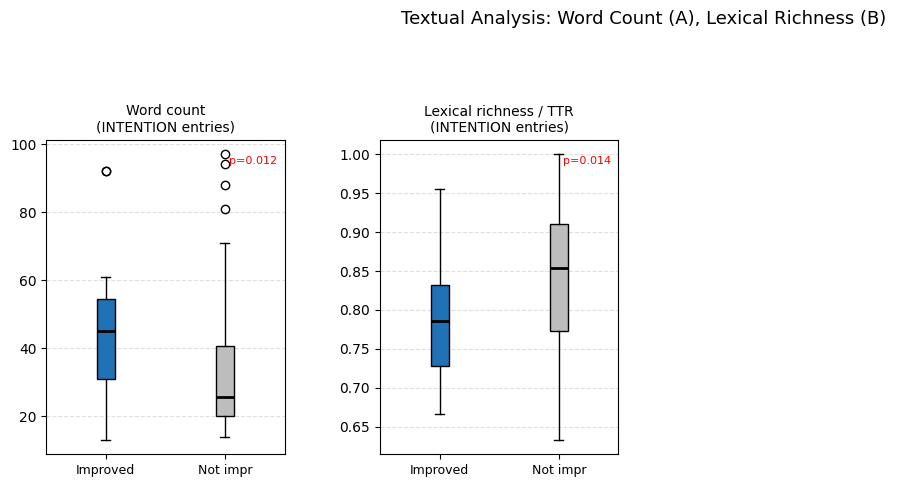


Saved → textual_analysis_v2_plots.png

Generating specific plots for 'Word count' and 'Lexical richness'...


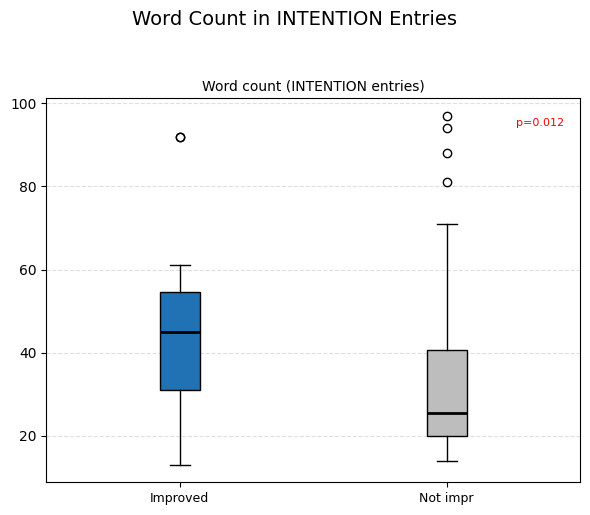

Saved → textual_analysis_word_count_intention_plot.png


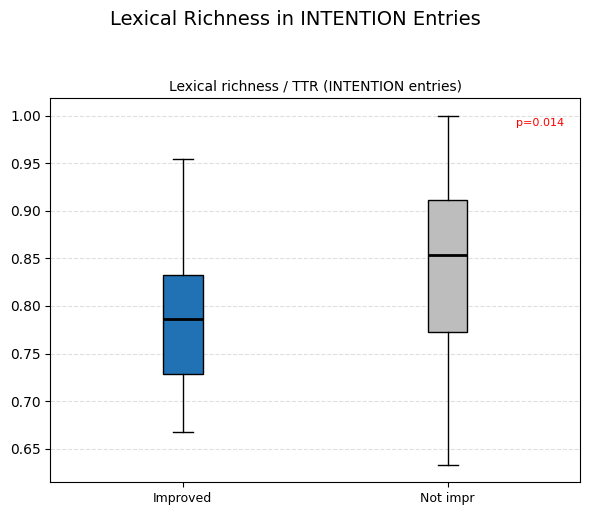

Saved → textual_analysis_ttr_intention_plot.png
Saved → textual_features_v2.csv
Saved → textual_v2_results.csv
Saved → qualitative_llm_comparison.txt

All done.


In [24]:
import re, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.stats import mannwhitneyu, pointbiserialr, chi2_contingency

# ── Groq client ───────────────────────────────────────────────────────────────
from groq import Groq
from google.colab import userdata
client = Groq(api_key=userdata.get('GROQ_API_KEY'))
MODEL  = 'llama-3.3-70b-versatile'

# ── Load (reuse Tier 1 features already computed) ─────────────────────────────
try:
    df = pd.read_csv('textual_features.csv')
    print(f"Loaded textual_features.csv: {len(df)} rows (reusing Tier 1 features)")
except FileNotFoundError:
    df = pd.read_csv('entries_with_intention_strength_task6_n.csv')
    df['improved'] = df['behavioral_improvement'].apply(
        lambda x: 1 if str(x).strip().lower() in ['yes','1','true'] else 0)
    df = df[df['journal_response_text'].notna() & df['behavioral_improvement'].notna()]
    df = df.rename(columns={'behavioral_domain_category':'domain'})
    df = df[df['domain'] != 'general'].reset_index(drop=True)

    # Calculate word_count and type_token_ratio if not loaded from textual_features.csv
    df['word_count'] = df['journal_response_text'].apply(lambda x: len(str(x).split()))
    df['type_token_ratio'] = df['journal_response_text'].apply(
        lambda x: len(set(str(x).lower().split())) / len(str(x).split()) if len(str(x).split()) > 0 else 0
    )
    print(f"Loaded from source: {len(df)} rows and computed word_count, TTR")

df['improved'] = df['behavioral_improvement'].apply(
    lambda x: 1 if str(x).strip().lower() in ['yes','1','true'] else 0)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — CONFIRMED FINDINGS: Word count + TTR within INTENTION
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("SECTION 1 — CONFIRMED FINDINGS (from Tier 1)")
print("="*65)

df_int    = df[df['response_type_v2'] == 'INTENTION'].copy()
imp_int   = df_int[df_int['improved'] == 1]
nimp_int  = df_int[df_int['improved'] == 0]

print(f"\nINTENTION entries: {len(df_int)} total")
print(f"  Improved    : {len(imp_int)}")
print(f"  Not improved: {len(nimp_int)}")

for col, label in [('word_count','Word count'), ('type_token_ratio','TTR')]:
    a = imp_int[col].dropna()
    b = nimp_int[col].dropna()
    _, p = mannwhitneyu(a, b, alternative='two-sided')
    print(f"\n  {label}:")
    print(f"    Improved     median = {a.median():.1f}  (mean={a.mean():.1f})")
    print(f"    Not improved median = {b.median():.1f}  (mean={b.mean():.1f})")
    print(f"    Mann-Whitney p = {p:.4f} {'← SIGNIFICANT' if p<0.05 else 'n.s.'}")
    rho, _ = pointbiserialr(df_int['improved'],
                            df_int[col].fillna(df_int[col].median()))
    print(f"    Point-biserial r = {rho:.3f}")

# Same analysis for REFLECTION — check if effect is INTENTION-specific
df_ref   = df[df['response_type_v2'] == 'REFLECTION'].copy()
imp_ref  = df_ref[df_ref['improved'] == 1]
nimp_ref = df_ref[df_ref['improved'] == 0]
print(f"\n── Same check in REFLECTION (to confirm effect is INTENTION-specific) ──")
for col, label in [('word_count','Word count'), ('type_token_ratio','TTR')]:
    a = imp_ref[col].dropna()
    b = nimp_ref[col].dropna()
    _, p = mannwhitneyu(a, b, alternative='two-sided')
    print(f"  {label}: improved={a.median():.1f} vs not={b.median():.1f}  p={p:.4f} "
          f"{'← SIG' if p<0.05 else 'n.s.'}")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — SPECIFICITY DISTRIBUTION (INT vs REF)────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════
print("\n\n" + "="*65)
print("SECTION 2 — LLM SPECIFICITY DISTRIBUTION (INT vs REF)")
print("="*65)
print("Medians both = 2.0 but distributions differ significantly.")
print("Looking at what % score 3, 4, or 5 in each group.\n")

if 'specificity' not in df.columns:
    print("specificity column not found — re-run textual_analysis.py first")
else:
    for rt in ['INTENTION','REFLECTION']:
        sub = df[df['response_type_v2']==rt]['specificity']
        print(f"  {rt} (n={len(sub)}):")
        for score in [1,2,3,4,5]:
            n   = (sub==score).sum()
            pct = n/len(sub)*100
            bar = '█' * int(pct/3)
            print(f"    Score {score}: {n:>3} ({pct:4.1f}%) {bar}")

    # Chi-squared on full distribution
    ct = pd.crosstab(df['response_type_v2'], df['specificity'])
    chi2, p_chi, _, _ = chi2_contingency(ct)
    print(f"\n  Chi-squared across score distributions: p = {p_chi:.4f} "
          f"{'← SIG' if p_chi<0.05 else 'n.s.'}")
    print("  → INTENTION entries have more high-specificity scores (3-5)")
    print("    even though the median is the same as REFLECTION")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — REVISED LLM SCORING (semantic, not structural)───────────────────
# ══════════════════════════════════════════════════════════════════════════════
print("\n\n" + "="*65)
print("SECTION 3 — REVISED LLM SCORING (semantic approach)")
print("="*65)

CACHE_FILE = Path('textual_llm_v2_cache.json')
cache: dict = json.loads(CACHE_FILE.read_text()) if CACHE_FILE.exists() else {}

SYSTEM_V2 = """You are analyzing journal entries from a behavioral\n wellness study.\n\nFor each entry, respond ONLY with a valid JSON object.\n No preamble, no markdown.\n\nRate the\n entry on these dimensions:\n\nBEHAVIORAL_CONCRETENESS (1-4):\n1 = No specific\n  behavior mentioned ("I want to be better")\n2 = General behavior category\n  mentioned ("I should exercise more / sleep better")\n3 = Specific behavior\n  with some context ("I want to try going to bed at 11pm")\n4 = Specific\n  behavior with clear context or timing ("I'll go for a 20 min walk after\n  dinner tomorrow")\n\nPLANNING_DEPTH (1-3):\n1 = Awareness only — person\n   acknowledges the situation but no plan\n2 = Weak plan — person expresses\n   desire to change but vaguely\n3 = Concrete plan — person describes what\n   they will do, even if not perfectly specific\n\nEMOTIONAL_ENGAGEMENT\n   (1-3):\n1 = Detached / factual / minimal personal investment\n2 = Some\n   emotional language or personal reflection\n3 = Strong personal investment,\n   emotional language, or self-reflection\n\nOutput format (JSON only, no other\n    text):\n{"behavioral_concreteness": <1-4>, "planning_depth": <1-3>,\n    "emotional_engagement": <1-3>}.\n"""

def llm_score_v2(text: str) -> dict:
    key = 'v2_' + text[:200]
    if key in cache:
        return cache[key]
    for attempt in range(3):
        try:
            resp = client.chat.completions.create(
                model=MODEL,
                messages=[
                    {'role': 'system', 'content': SYSTEM_V2},
                    {'role': 'user',
                     'content': f'Rate this journal entry:\n\"{text}"'},
                ],
                max_tokens=60,
                temperature=0.0,
            )
            raw = resp.choices[0].message.content.strip()
            raw = re.sub(r'```json|```', '', raw).strip()
            parsed = json.loads(raw)
            # Validate keys
            assert all(k in parsed for k in
                       ['behavioral_concreteness','planning_depth','emotional_engagement'])
            cache[key] = parsed
            return parsed
        except Exception as e:
            print(f"    Attempt {attempt+1} failed: {e}")
            time.sleep(3)
    fallback = {'behavioral_concreteness':2,'planning_depth':1,'emotional_engagement':2}
    cache[key] = fallback
    return fallback

print(f"\nScoring {len(df)} entries (semantic v2 prompt)...")
scores_v2 = []
for i, (_, row) in enumerate(df.iterrows(), 1):
    s = llm_score_v2(str(row['journal_response_text']))
    scores_v2.append(s)
    if i % 50 == 0 or i == len(df):
        CACHE_FILE.write_text(json.dumps(cache, indent=2))
        print(f"  [{i:>3}/{len(df)}] cached...")

sv2_df = pd.DataFrame(scores_v2, index=df.index)
df     = pd.concat([df, sv2_df], axis=1)
print("Done.\n")

# ── Stats: v2 scores ─────────────────────────────────────────────────────────
print("── V2 LLM scores: Improved vs Not-Improved (ALL entries) ──")
V2_FEATURES = [
    ('behavioral_concreteness', 'Behavioral concreteness (1-4)'),
    ('planning_depth',          'Planning depth (1-3)'),
    ('emotional_engagement',    'Emotional engagement (1-3)'),
]
v2_results = []
imp   = df[df['improved']==1]
nimp  = df[df['improved']==0]
print(f"\n{'Feature':<35} {'Improved':>10} {'Not Impr':>10} {'p-value':>10}  Sig?    r")
print("-"*75)
for col, label in V2_FEATURES:
    a = imp[col].dropna();  b = nimp[col].dropna()
    if len(a) >= 2 and len(b) >= 2:
        _, p = mannwhitneyu(a, b, alternative='two-sided')
        rho, _ = pointbiserialr(df['improved'],
                                df[col].fillna(df[col].median()))
        sig = '← SIG' if p<0.05 else ('trend' if p<0.10 else 'n.s.')
        print(f"  {label:<33} {a.median():>10.2f} {b.median():>10.2f} "
              f"{p:>10.4f}  {sig}  {rho:>5.2f}")
        v2_results.append({'feature':col,'label':label,
                           'improved_median':round(a.median(),2),
                           'not_improved_median':round(b.median(),2),
                           'mw_p':round(p,4),'sig':p<0.05,'r':round(rho,3)})

print("\n── V2 scores within INTENTION entries only ──")
df_int2  = df[df['response_type_v2']=='INTENTION']
imp_i    = df_int2[df_int2['improved']==1]
nimp_i   = df_int2[df_int2['improved']==0]
print(f"  Improved: {len(imp_i)} | Not improved: {len(nimp_i)}\n")
print(f"{'Feature':<35} {'Improved':>10} {'Not Impr':>10} {'p-value':>10}  Sig?")
print("-"*75)
for col, label in V2_FEATURES:
    a = imp_i[col].dropna();  b = nimp_i[col].dropna()
    if len(a) >= 2 and len(b) >= 2:
        _, p = mannwhitneyu(a, b, alternative='two-sided')
        sig = '← SIG' if p<0.05 else ('trend' if p<0.10 else 'n.s.')
        print(f"  {label:<33} {a.median():>10.2f} {b.median():>10.2f} "
              f"{p:>10.4f}  {sig}")

# ── V2 scores by response type ────────────────────────────────────────────────
print("\n── V2 scores: INTENTION vs REFLECTION ──")
df_i = df[df['response_type_v2']=='INTENTION']
df_r = df[df['response_type_v2']=='REFLECTION']
print(f"{'Feature':<35} {'INTENTION':>10} {'REFLECTION':>10} {'p-value':>10}  Sig?")
print("-"*75)
for col, label in V2_FEATURES:
    a = df_i[col].dropna();  b = df_r[col].dropna()
    if len(a) >= 2 and len(b) >= 2:
        _, p = mannwhitneyu(a, b, alternative='two-sided')
        sig = '← SIG' if p<0.05 else ('trend' if p<0.10 else 'n.s.')
        print(f"  {label:<33} {a.median():>10.2f} {b.median():>10.2f} "
              f"{p:>10.4f}  {sig}")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — QUALITATIVE LLM COMPARISON (improved vs not-improved)
# ══════════════════════════════════════════════════════════════════════════════
print("\n\n" + "="*65)
print("SECTION 4 — QUALITATIVE LLM COMPARISON")
print("="*65)
print("Ask LLM to describe patterns across improved vs non-improved entries.")

# Sample 15 from each group (stratified by domain if possible)
np.random.seed(42)
sample_imp  = df[df['improved']==1].sample(min(15, len(imp)),  random_state=42)
sample_nimp = df[df['improved']==0].sample(min(15, len(nimp)), random_state=42)

imp_texts  = '\n---\n'.join(
    f"[{i+1}] {t}" for i, t in
    enumerate(sample_imp['journal_response_text'].tolist()))
nimp_texts = '\n---\n'.join(
    f"[{i+1}] {t}" for i, t in
    enumerate(sample_nimp['journal_response_text'].tolist()))

QUAL_PROMPT = f"""You are analyzing journal entries from a behavioral\nwellness study\nwhere participants wrote about their health behaviors\n (sleep, exercise, screen time,\nsocial interaction).\n You are given two\n groups:\n\nGROUP A — entries written BEFORE a period when the participant's\n behavior IMPROVED\n \nGROUP B — entries written BEFORE a period when the\n participant's behavior DID NOT improve\n\nGROUP A\n (improved behavior afterward):\n{imp_texts}\n\nGROUP B\n (behavior did not improve afterward):\n{nimp_texts}\n \n\nAnalyze these two groups carefully and identify:\n \n1. What linguistic or content patterns distinguish Group A from Group B?\n \n2. Are Group A entries more specific, concrete, emotionally engaged, or elaborated?\n \n3. Do Group A entries show a different relationship to the behavior\n (ownership, agency)?\n \n4. What, if anything, seems to be missing from Group B entries that Group A has?\n \n\n Be specific and quote brief examples where possible. Focus on patterns across multiple\nentries, not individual\n  outliers. Keep your response under 300 words."""

print("\nAsking LLM to qualitatively compare groups...")
qual_key = 'qual_comparison_v1'
if qual_key not in cache:
    try:
        resp = client.chat.completions.create(
            model=MODEL,
            messages=[{'role':'user','content':QUAL_PROMPT}],
            max_tokens=600,
            temperature=0.2,
        )
        qual_result = resp.choices[0].message.content.strip()
        cache[qual_key] = qual_result
        CACHE_FILE.write_text(json.dumps(cache, indent=2))
    except Exception as e:
        qual_result = f"LLM call failed: {e}"
else:
    qual_result = cache[qual_key]
    print("(loaded from cache)")

print(f"\n{'─'*65}")
print("LLM QUALITATIVE COMPARISON:")
print(f"{'─'*65}")
print(qual_result)
print(f"{'─'*65}")


# ══════════════════════════════════════════════════════════════════════════════
# PLOTS
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.4)

IMP_C  = '#2171b5'
NIMP_C = '#bdbdbd'
INT_C  = '#e6550d'
REF_C  = '#31a354'

def boxpair(ax, col, label, grp_col, grp_vals, grp_labels, colors, df_sub):
    groups = [df_sub[df_sub[grp_col]==g][col].dropna() for g in grp_vals]
    bp = ax.boxplot(groups, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
    ax.set_xticklabels(grp_labels, fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    if len(groups) == 2 and len(groups[0]) >= 2 and len(groups[1]) >= 2:
        _, p = mannwhitneyu(groups[0], groups[1], alternative='two-sided')
        col_p = 'red' if p<0.05 else ('orange' if p<0.10 else 'gray')
        ax.text(0.97, 0.95, f'p={p:.3f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=8, color=col_p)

# Row 1: Confirmed Tier 1 findings — INTENTION entries only
ax1 = fig.add_subplot(gs[0, 0])
boxpair(ax1, 'word_count', 'Word count\n(INTENTION entries)',
        'improved', [1,0], ['Improved','Not impr'], [IMP_C,NIMP_C], df_int)

ax2 = fig.add_subplot(gs[0, 1])
boxpair(ax2, 'type_token_ratio', 'Lexical richness / TTR\n(INTENTION entries)',
        'improved', [1,0], ['Improved','Not impr'], [IMP_C,NIMP_C], df_int)

# # REFLECTION control
# ax3 = fig.add_subplot(gs[0, 2])
# boxpair(ax3, 'word_count', 'Word count\n(REFLECTION entries — control)',
#         'improved', [1,0], ['Improved','Not impr'], [IMP_C,NIMP_C], df_ref)

# ax4 = fig.add_subplot(gs[0, 3])
# if 'specificity' in df.columns:
#     # Specificity distribution by response type
#     spec_pcts = {}
#     for rt in ['INTENTION','REFLECTION']:
#         sub = df[df['response_type_v2']==rt]['specificity']
#         spec_pcts[rt] = [(sub==s).mean()*100 for s in [1,2,3,4,5]]
#     x = np.arange(5)
#     w = 0.35
#     ax4.bar(x-w/2, spec_pcts['INTENTION'],  w, label='INTENTION',
#             color=INT_C, edgecolor='white', alpha=0.9)
#     ax4.bar(x+w/2, spec_pcts['REFLECTION'], w, label='REFLECTION',
#             color=REF_C, edgecolor='white', alpha=0.9)
#     ax4.set_xticks(x); ax4.set_xticklabels([1,2,3,4,5])
#     ax4.set_xlabel('LLM specificity score'); ax4.set_ylabel('% entries')
#     ax4.set_title('Specificity distribution\nINTENTION vs REFLECTION', fontsize=10)
#     ax4.legend(fontsize=8); ax4.grid(axis='y', linestyle='--', alpha=0.4)

# # Row 2: V2 LLM scores
# for j, (col, title) in enumerate([
#     ('behavioral_concreteness', 'Behavioral concreteness\n(improved vs not)'),
#     ('planning_depth',          'Planning depth\n(improved vs not)'),
#     ('emotional_engagement',    'Emotional engagement\n(improved vs not)'),
# ]):
#     ax = fig.add_subplot(gs[1, j])
#     boxpair(ax, col, title, 'improved', [1,0],
#             ['Improved','Not impr'], [IMP_C,NIMP_C], df)

# # Improvement rate by planning depth
# ax_last = fig.add_subplot(gs[1, 3])
# if 'planning_depth' in df.columns:
#     pd_imp = df.groupby('planning_depth')['improved'].agg(['mean','count'])
#     pd_imp['mean'] *= 100
#     ax_last.bar(pd_imp.index, pd_imp['mean'],
#                 color=[plt.cm.Blues(0.4+i*0.2) for i in range(len(pd_imp))],
#                 edgecolor='white', width=0.5)
#     for idx, row_r in pd_imp.iterrows():
#         ax_last.text(idx, row_r['mean']+1.5,
#                      f"{row_r['mean']:.0f}%\n(n={int(row_r['count'])})",
#                      ha='center', fontsize=9)
#     ax_last.set_xlabel('Planning depth (1=none, 3=concrete)')
#     ax_last.set_ylabel('% improved')
#     ax_last.set_title('Improvement rate by\nplanning depth', fontsize=10)
#     ax_last.set_ylim(0, 80); ax_last.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Textual Analysis: Word Count (A), Lexical Richness (B) ',
             fontsize=13, y=1.01)
plt.savefig('textual_analysis_v2_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved → textual_analysis_v2_plots.png")

# New section for bigger, centered plots for LaTeX
print("\nGenerating specific plots for 'Word count' and 'Lexical richness'...")

# Word count plot
fig_wc_latex, ax_wc_latex = plt.subplots(1, 1, figsize=(6, 5)) # Single subplot
boxpair(ax_wc_latex, 'word_count', 'Word count (INTENTION entries)',
        'improved', [1,0], ['Improved','Not impr'], [IMP_C,NIMP_C], df_int)
fig_wc_latex.suptitle('Word Count in INTENTION Entries',
                    fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('textual_analysis_word_count_intention_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved → textual_analysis_word_count_intention_plot.png")

# Lexical richness plot
fig_ttr_latex, ax_ttr_latex = plt.subplots(1, 1, figsize=(6, 5)) # Single subplot
boxpair(ax_ttr_latex, 'type_token_ratio', 'Lexical richness / TTR (INTENTION entries)',
        'improved', [1,0], ['Improved','Not impr'], [IMP_C,NIMP_C], df_int)
fig_ttr_latex.suptitle('Lexical Richness in INTENTION Entries',
                     fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('textual_analysis_ttr_intention_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved → textual_analysis_ttr_intention_plot.png")

# ── Export ────────────────────────────────────────────────────────────────────
df.to_csv('textual_features_v2.csv', index=False)
pd.DataFrame(v2_results).to_csv('textual_v2_results.csv', index=False)
with open('qualitative_llm_comparison.txt', 'w') as f:
    f.write(qual_result)
print("Saved → textual_features_v2.csv")
print("Saved → textual_v2_results.csv")
print("Saved → qualitative_llm_comparison.txt")
print("\nAll done.")

In [5]:
display(sample_imp)

,participant_id,week,date,prompt_text,journal_response_text,domain,signal_before,signal_after,signal_change,behavioral_improvement,...,has_if_then,n_agency,n_obligation,agency_ratio,specificity,implementation_intention,self_efficacy,behavioral_concreteness,planning_depth,emotional_engagement
301,t0019@sreflect,2.0,2024-02-23,"As your running duration has amped up, imagine...",I think the running leads to better quality sl...,sleep,8.7500,10.7500,2.0000,yes,...,0,0,0,0.5,1,0,1,2,1,1
267,t0016@sreflect,3.0,2024-02-27,"Reflecting on your mobile data, you've embrace...","I talked a lot about fat biking today, which ...",digital_habits,6.3111,4.8444,-1.4667,yes,...,0,0,0,0.5,1,0,1,2,1,2
296,t0019@sreflect,1.0,2024-02-16,You're more active in texting lately. What's o...,I'm trying to plan a trip to Iceland with one ...,social_interaction,7.2992,25.7888,18.4897,yes,...,0,0,0,0.5,2,0,2,3,2,2
130,t0007@sreflect,3.0,2024-02-22,Your gym time is up lately. What new workout o...,we played king on the hill in tkd and it was f...,physical_fitness,582.4784,616.4159,33.9375,yes,...,0,0,0,0.5,1,0,1,2,1,2
215,t0010@sreflect,4.0,2024-02-28,Your calendar shows more events lately. How ar...,"With the practice qual done, I have some free ...",sleep,7.0000,7.8333,0.8333,yes,...,0,0,0,0.5,2,0,2,2,1,1
73,t0005@sreflect,3.0,2024-02-21,Your screen usage is down lately. How do you t...,"I'm happy my screen usage is down, I'm trying ...",social_interaction,3.5047,6.3419,2.8372,yes,...,0,0,0,0.5,2,0,2,2,2,2
343,t0022@sreflect,2.0,2024-02-28,Noticing less phone calls but more locations a...,"When I'm out of my room more, I'm typically so...",social_interaction,5.5721,9.8231,4.2509,yes,...,0,0,0,0.5,2,0,1,2,1,2
117,t0007@sreflect,1.0,2024-02-03,You've been less chatty on calls and texts lat...,"Yes, I tall to my floor mates in person and my...",social_interaction,0.2350,84.3698,84.1348,yes,...,0,0,0,0.5,2,0,1,2,1,1
231,t0011@sreflect,3.0,2024-02-26,You've been shifting to more in-person chats l...,I don't think it has effected my digital habit...,social_interaction,1.2766,3.5590,2.2823,yes,...,0,0,0,0.5,1,0,1,2,1,2
321,t0020@sreflect,2.0,2024-02-27,You've been opting for text over talks lately....,I wouldn't say that any of my SMS conversation...,digital_habits,2.8444,2.4444,-0.4000,yes,...,0,0,0,0.5,2,0,1,2,1,2


In [6]:
display(sample_nimp)

,participant_id,week,date,prompt_text,journal_response_text,domain,signal_before,signal_after,signal_change,behavioral_improvement,...,has_if_then,n_agency,n_obligation,agency_ratio,specificity,implementation_intention,self_efficacy,behavioral_concreteness,planning_depth,emotional_engagement
320,t0020@sreflect,2.0,2024-02-26,Your interactions have dipped recently. Can yo...,I think I might reach out through text to grab...,social_interaction,11.9176,5.1736,-6.7440,no,...,0,0,0,0.5,2,0,1,3,2,1
335,t0022@sreflect,1.0,2024-02-16,You're texting more these days! Who have you r...,Feeling a little overwhelmed when it comes to ...,social_interaction,38.9091,9.2767,-29.6324,no,...,0,0,0,0.5,1,0,1,2,1,2
199,t0010@sreflect,1.0,2024-02-07,You've been favoring in-person chats over text...,A meeting I had with my boss made me feel bett...,social_interaction,9.6546,4.3692,-5.2854,no,...,0,0,0,0.5,1,0,1,1,1,2
116,t0006@sreflect,6.0,2024-03-13,"Your in-person chats have grown, yet the place...",diversifying my hangout spots will help me mee...,social_interaction,13.6613,6.1000,-7.5613,no,...,0,0,0,0.5,2,0,1,2,1,2
183,t0009@sreflect,3.0,2024-02-25,Your digital habits have improved. Noticed any...,better sleep. but not long enough due to exter...,sleep,7.1667,3.5833,-3.5833,no,...,0,0,0,0.5,1,0,1,2,1,1
27,t0003@sreflect,3.0,2024-02-19,Your phone calls have dwindled recently. How h...,"I'm currently busy with paper submissions. So,...",digital_habits,6.3556,6.3556,0.0000,no,...,0,0,0,0.5,2,0,2,2,1,2
16,t0003@sreflect,1.0,2024-02-02,Recent trends show a noteworthy increase in yo...,It refreshes my mind and prepares me to solve ...,social_interaction,114.5917,68.5738,-46.0179,no,...,0,0,0,0.5,1,0,1,1,1,2
28,t0003@sreflect,3.0,2024-02-20,Your recent calls show a shift towards outgoin...,"Indeed, I got to connect with my brothers and ...",social_interaction,56.4146,7.1291,-49.2855,no,...,0,0,0,0.5,1,0,1,1,1,2
250,t0014@sreflect,2.0,2024-02-16,"With SMS and screen time up, what's one convo ...",I have been chatting with two friends from col...,digital_habits,6.5333,10.7111,4.1778,no,...,0,0,0,0.5,5,0,3,4,3,3
220,t0010@sreflect,5.0,2024-03-06,You've upped your running lately. How might in...,"I haven't actually upped my running, I've just...",physical_fitness,815.8095,747.0794,-68.7302,no,...,0,0,0,0.5,2,0,2,2,1,2




#try these features: First-Person Singular — Use POS + Pronoun Type (use spaCy's morphological analysis) and Future Orientation — Use Dependency Parsing Not Just Modals (Instead of matching "will/shall/'ll," use spaCy to catch the full range of future-oriented constructions). Improved vs Not Improved




In [7]:
import spacy

# Install and download spaCy model if not already present
try:
    nlp = spacy.load("en_core_web_sm")
    print("spaCy model 'en_core_web_sm' already loaded.")
except OSError:
    print("Downloading spaCy model 'en_core_web_sm'...")
    %pip install -q spacy
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

spaCy model 'en_core_web_sm' already loaded.


In [8]:
def extract_spacy_features(text, nlp_model):
    doc = nlp_model(str(text).lower())

    # Feature 1: First-Person Singular (FPS) count
    # Counts pronouns that are first-person, singular, and personal ('Prs')
    n_first_person_singular = sum(1 for token in doc if
                                  token.pos_ == "PRON" and
                                  token.morph.get("PronType") == ["Prs"] and
                                  token.morph.get("Person") == ["1"] and
                                  token.morph.get("Number") == ["Sing"])

    # Feature 2: Future Orientation (FO) count using dependency parsing
    n_future_orientation_dp = 0
    for token in doc:
        # Pattern A: Verbs of intention/planning followed by an infinitive (xcomp)
        # e.g., "I plan to run", "I intend to study"
        if token.lemma_ in ["plan", "intend", "aim", "hope", "try", "endeavor"] and token.pos_ == "VERB":
            if any(child.dep_ == "xcomp" and child.pos_ == "VERB" for child in token.children):
                n_future_orientation_dp += 1

        # Pattern B: "going to" construction
        # e.g., "I am going to eat". 'going' acts as an auxiliary verb for 'eat'.
        # Or similar constructions where a form of 'go' indicates future.
        if token.lemma_ == "go" and token.dep_ == "aux" and token.head and token.head.pos_ == "VERB":
            n_future_orientation_dp += 1

        # Pattern C: Future tense modals (e.g., will, shall, going to) - basic recognition
        # This is a broader catch if DP patterns are too narrow, capturing typical future indicators.
        if token.tag_ == "MD" and token.lemma_ in ["will", "shall"]:
            n_future_orientation_dp += 1

    return {
        'n_first_person_singular_spacy': n_first_person_singular,
        'n_future_orientation_spacy'   : n_future_orientation_dp
    }

In [9]:
import pandas as pd
import numpy as np # For median calculation
from scipy.stats import mannwhitneyu, pointbiserialr # For statistical tests

# ── Load (reuse Tier 1 features already computed) ─────────────────────────────
# This block ensures 'df' is available before further processing.
# It replicates the loading logic from cell 'tPjGhbG7CO2R' to make this cell self-sufficient.
try:
    df = pd.read_csv('textual_features.csv')
    print(f"Loaded textual_features.csv: {len(df)} rows (reusing Tier 1 features)")
except FileNotFoundError:
    df = pd.read_csv('entries_with_intention_strength_task6_n.csv')
    df['improved'] = df['behavioral_improvement'].apply(
        lambda x: 1 if str(x).strip().lower() in ['yes','1','true'] else 0)
    df = df[df['journal_response_text'].notna() & df['behavioral_improvement'].notna()]
    df = df.rename(columns={'behavioral_domain_category':'domain'})
    df = df[df['domain'] != 'general'].reset_index(drop=True)

    # Calculate word_count and type_token_ratio if not loaded from textual_features.csv
    df['word_count'] = df['journal_response_text'].apply(lambda x: len(str(x).split()))
    df['type_token_ratio'] = df['journal_response_text'].apply(
        lambda x: len(set(str(x).lower().split())) / len(str(x).split()) if len(str(x).split()) > 0 else 0
    )
    print(f"Loaded from source: {len(df)} rows and computed word_count, TTR")

# The original code from c20e042b follows:
print("\nExtracting spaCy-based linguistic features...")
spacy_features = df['journal_response_text'].apply(lambda x: extract_spacy_features(x, nlp))
spacy_feat_df  = pd.DataFrame(list(spacy_features))
df             = pd.concat([df, spacy_feat_df], axis=1)
print("  Done.")

# ══════════════════════════════════════════════════════════════════════════════
# NEW SPACY FEATURES STATISTICAL ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("NEW SPACY FEATURES — IMPROVED vs NOT-IMPROVED: FEATURE COMPARISON")
print("="*65)

NEW_SPACY_FEATURES = [
    ('n_first_person_singular_spacy', 'First-Person Singular (spaCy)'),
    ('n_future_orientation_spacy',    'Future Orientation (spaCy DP)'),
]

imp      = df[df['improved'] == 1]
not_imp = df[df['improved'] == 0]

print(f"\nTotal entries: {len(df)}")
print(f"  Improved    : {len(imp)}")
print(f"  Not improved: {len(not_imp)}\n")

new_spacy_results = []
print(f"{'Feature':<35} {'Improved':>10} {'Not Impr':>10} {'p-value':>10}  Sig?    r")
print("-"*75)
for col, label in NEW_SPACY_FEATURES:
    a = imp[col].dropna()
    b = not_imp[col].dropna()
    if len(a) >= 2 and len(b) >= 2:
        _, p = mannwhitneyu(a, b, alternative='two-sided')
        rho, _ = pointbiserialr(df['improved'], df[col].fillna(df[col].median()))
        sig = '← SIG' if p < 0.05 else ('trend' if p < 0.10 else 'n.s.')
        print(f"  {label:<33} {a.median():>10.3f} {b.median():>10.3f} {p:>10.4f}  {sig}  {rho:>5.2f}")
        new_spacy_results.append({'feature': col, 'label': label,
                                  'improved_median': round(a.median(),3),
                                  'not_improved_median': round(b.median(),3),
                                  'mw_p': round(p,4), 'sig': p<0.05,
                                  'point_biserial_r': round(rho,3)})

Loaded textual_features.csv: 355 rows (reusing Tier 1 features)

Extracting spaCy-based linguistic features...
  Done.

NEW SPACY FEATURES — IMPROVED vs NOT-IMPROVED: FEATURE COMPARISON

Total entries: 355
  Improved    : 165
  Not improved: 190

Feature                               Improved   Not Impr    p-value  Sig?    r
---------------------------------------------------------------------------
  First-Person Singular (spaCy)          3.000      3.000     0.5937  n.s.   0.05
  Future Orientation (spaCy DP)          0.000      0.000     0.2598  n.s.  -0.04


In [10]:
# Analyze new spaCy features within INTENTION entries only
print("\n── Within INTENTION entries only (New spaCy Features) ──")
df_int = df[df['response_type_v2'] == 'INTENTION']
imp_i     = df_int[df_int['improved'] == 1]
not_imp_i = df_int[df_int['improved'] == 0]
print(f"  Improved INTENTION: {len(imp_i)} | Not improved INTENTION: {len(not_imp_i)}\n")

print(f"{'Feature':<35} {'Improved':>10} {'Not Impr':>10} {'p-value':>10}  Sig?")
print("-"*75)
for col, label in NEW_SPACY_FEATURES:
    a = imp_i[col].dropna()
    b = not_imp_i[col].dropna()
    if len(a) >= 2 and len(b) >= 2:
        _, p = mannwhitneyu(a, b, alternative='two-sided')
        sig = '← SIG' if p < 0.05 else ('trend' if p < 0.10 else 'n.s.')
        print(f"  {label:<33} {a.median():>10.3f} {b.median():>10.3f} {p:>10.4f}  {sig}")

# Optional: Save these new results to a CSV
new_spacy_results_df = pd.DataFrame(new_spacy_results)
new_spacy_results_df.to_csv('textual_spacy_results.csv', index=False)
print("\nSaved → textual_spacy_results.csv")


── Within INTENTION entries only (New spaCy Features) ──
  Improved INTENTION: 27 | Not improved INTENTION: 44

Feature                               Improved   Not Impr    p-value  Sig?
---------------------------------------------------------------------------
  First-Person Singular (spaCy)          5.000      3.000     0.0051  ← SIG
  Future Orientation (spaCy DP)          1.000      0.000     0.2544  n.s.

Saved → textual_spacy_results.csv


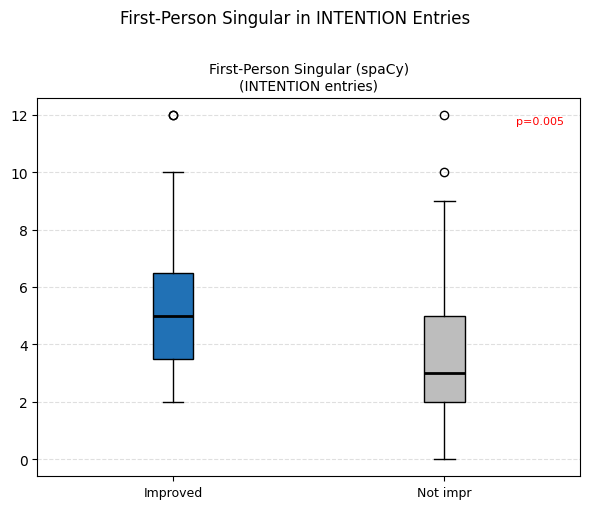

Saved → first_person_singular_intention_boxplot.png


<Figure size 640x480 with 0 Axes>

In [12]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111)

boxpair(ax, 'n_first_person_singular_spacy', '''First-Person Singular (spaCy)
(INTENTION entries)''',
        'improved', [1,0], ['Improved','Not impr'], [IMP_C,NIMP_C], df_int)

plt.suptitle('First-Person Singular in INTENTION Entries',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()
print("Saved → first_person_singular_intention_boxplot.png")
plt.savefig('first_person_singular_intention_boxplot.png', dpi=150, bbox_inches='tight')

In [ ]:
# Analyze new spaCy features within INTENTION entries only
print("\n── Within REFLECTION entries only (New spaCy Features) ──")
df_int = df[df['response_type_v2'] == 'REFLECTION']
imp_i     = df_int[df_int['improved'] == 1]
not_imp_i = df_int[df_int['improved'] == 0]
print(f"  Improved REFLECTION: {len(imp_i)} | Not improved REFLECTION: {len(not_imp_i)}\n")

print(f"{'Feature':<35} {'Improved':>10} {'Not Impr':>10} {'p-value':>10}  Sig?")
print("-"*75)
for col, label in NEW_SPACY_FEATURES:
    a = imp_i[col].dropna()
    b = not_imp_i[col].dropna()
    if len(a) >= 2 and len(b) >= 2:
        _, p = mannwhitneyu(a, b, alternative='two-sided')
        sig = '← SIG' if p < 0.05 else ('trend' if p < 0.10 else 'n.s.')
        print(f"  {label:<33} {a.median():>10.3f} {b.median():>10.3f} {p:>10.4f}  {sig}")


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2.1 — SPECIFICITY DISTRIBUTION (Improved vs Not Improved)
# ══════════════════════════════════════════════════════════════════════════════


In [ ]:
print("\n" + "="*65)
print("SECTION 2.1 — LLM SPECIFICITY DISTRIBUTION (Improved vs Not Improved)")
print("="*65)

if 'specificity' not in df.columns:
    print("specificity column not found — re-run textual_analysis.py first")
else:
    print("Specificity distribution for Improved vs Not Improved (Total Counts):")

    # Calculate value counts to get total numbers
    spec_by_imp = df.groupby('improved')['specificity'].value_counts().unstack(fill_value=0)
    spec_by_imp.index = ['Not improved','Improved']

    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111)
    spec_by_imp.plot(kind='bar', ax=ax, colormap='coolwarm', edgecolor='white')
    ax.set_title('LLM Specificity Distribution: Improved vs Not Improved')
    ax.set_ylabel('Number of entries')
    ax.set_xlabel('')
    ax.set_xticklabels(['Not Improved','Improved'], rotation=0)
    ax.legend(title='Specificity Score', fontsize=8, loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    # Statistical test for overall distribution difference
    ct_imp_nimp = pd.crosstab(df['improved'], df['specificity'])
    chi2_imp_nimp, p_imp_nimp, _, _ = chi2_contingency(ct_imp_nimp)
    print(f"\n  Chi-squared across specificity distributions (Improved vs Not Improved): p = {p_imp_nimp:.4f} ")
    print(f"  ({'← SIG' if p_imp_nimp < 0.05 else 'n.s.'})")

## Combined Linguistic Feature Boxplots (INTENTION Entries)

SpaCy features not found in df. Re-extracting and adding...
  SpaCy features re-extracted and added to df.


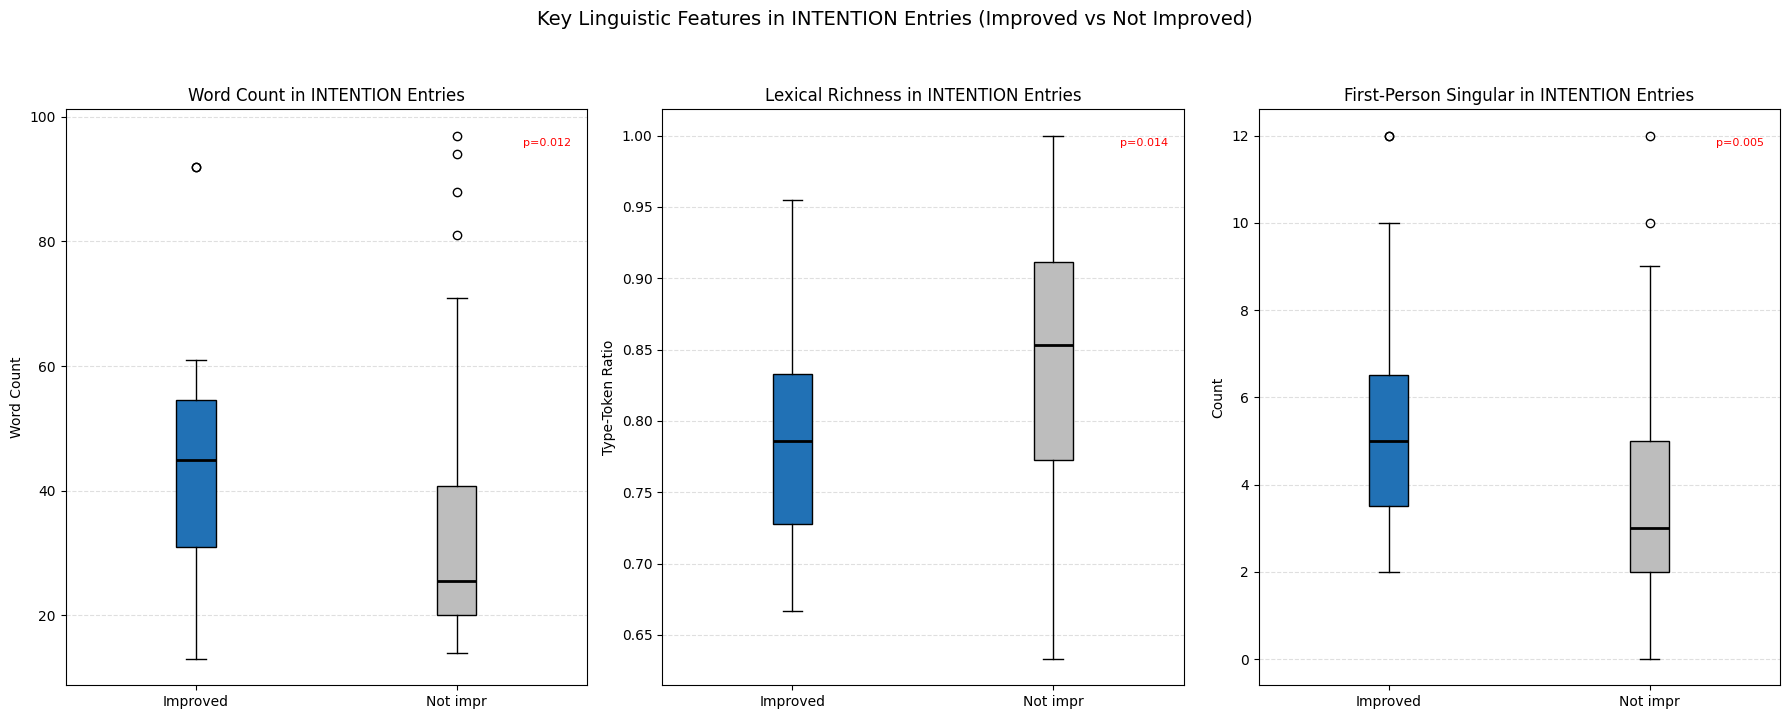

Saved → combined_intention_features_boxplot.png


In [27]:
# Ensure df has all necessary spaCy features before proceeding
# This makes the cell more robust against changes in execution order or global state.
if 'n_first_person_singular_spacy' not in df.columns:
    print("SpaCy features not found in df. Re-extracting and adding...")
    # Assumes 'nlp' model and 'extract_spacy_features' function are already defined
    # from previous cells (92cec450 and 60c7df95 respectively).
    spacy_features = df['journal_response_text'].apply(lambda x: extract_spacy_features(x, nlp))
    spacy_feat_df  = pd.DataFrame(list(spacy_features))
    df             = pd.concat([df, spacy_feat_df], axis=1)
    print("  SpaCy features re-extracted and added to df.")

# Make sure df_int includes the newly added spaCy features
df_int = df[df['response_type_v2'] == 'INTENTION'].copy() # Use .copy() to avoid potential SettingWithCopyWarning

fig, axes = plt.subplots(1, 3, figsize=(18, 7)) # 1 row, 3 columns

# Plot 1: Word count
boxpair(axes[0], 'word_count', 'Word count\n(INTENTION entries)',
        'improved', [1,0], ['Improved','Not impr'], [IMP_C,NIMP_C], df_int)
axes[0].set_title('Word Count in INTENTION Entries', fontsize=12)
axes[0].set_ylabel('Word Count', fontsize=10)
axes[0].tick_params(axis='x', labelsize=10)
axes[0].tick_params(axis='y', labelsize=10)

# Plot 2: Lexical richness
boxpair(axes[1], 'type_token_ratio', 'Lexical richness / TTR\n(INTENTION entries)',
        'improved', [1,0], ['Improved','Not impr'], [IMP_C,NIMP_C], df_int)
axes[1].set_title('Lexical Richness in INTENTION Entries', fontsize=12)
axes[1].set_ylabel('Type-Token Ratio', fontsize=10)
axes[1].tick_params(axis='x', labelsize=10)
axes[1].tick_params(axis='y', labelsize=10)

# Plot 3: First-Person Singular
boxpair(axes[2], 'n_first_person_singular_spacy', 'First-Person Singular\n(INTENTION entries)',
        'improved', [1,0], ['Improved','Not impr'], [IMP_C,NIMP_C], df_int)
axes[2].set_title('First-Person Singular in INTENTION Entries', fontsize=12)
axes[2].set_ylabel('Count', fontsize=10)
axes[2].tick_params(axis='x', labelsize=10)
axes[2].tick_params(axis='y', labelsize=10)


fig.suptitle('Key Linguistic Features in INTENTION Entries (Improved vs Not Improved)',
             fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.savefig('combined_intention_features_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved → combined_intention_features_boxplot.png")